Dataset Shape: (569, 30)
Target Shape: (569,)
Training Data: (398, 30)
Validation Data: (85, 30)
Testing Data: (86, 30)
Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=16, out_features=8, bias=True)
  (4): ReLU()
  (5): Linear(in_features=8, out_features=1, bias=True)
  (6): Sigmoid()
)
Epoch [1/100] | Train Loss: 0.7091 | Val Loss: 0.7149 | Train Accuracy: 0.5251 | Val Accuracy: 0.4824
Epoch [2/100] | Train Loss: 0.7028 | Val Loss: 0.7098 | Train Accuracy: 0.5653 | Val Accuracy: 0.5059
Epoch [3/100] | Train Loss: 0.6958 | Val Loss: 0.7046 | Train Accuracy: 0.5729 | Val Accuracy: 0.5176
Epoch [4/100] | Train Loss: 0.6936 | Val Loss: 0.6994 | Train Accuracy: 0.5955 | Val Accuracy: 0.5529
Epoch [5/100] | Train Loss: 0.6883 | Val Loss: 0.6942 | Train Accuracy: 0.6080 | Val Accuracy: 0.5647
Epoch [6/100] | Train Loss: 0.6815 | Val Loss: 0.6891 | Train Accuracy: 0.6030 | Val Accuracy: 0.5647
E

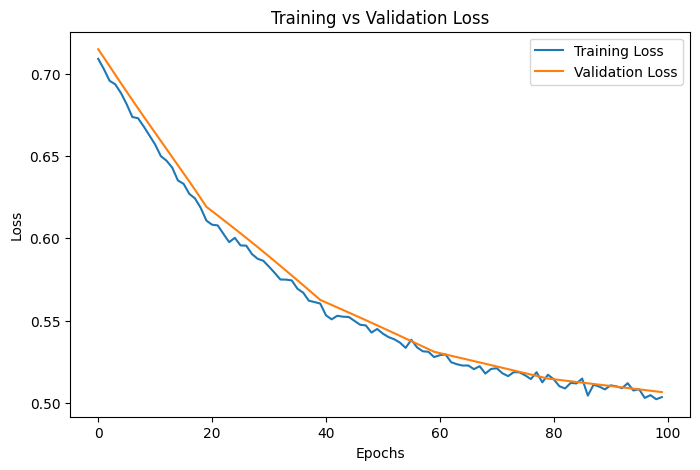

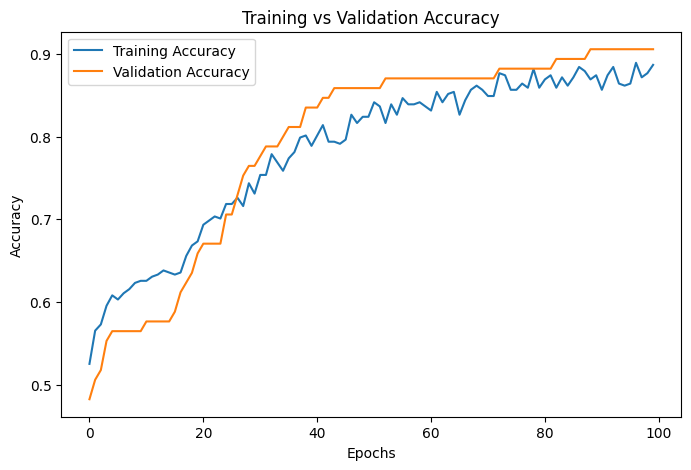


Final Test Loss: 0.48294249176979065
Final Test Accuracy: 0.9069767441860465

Experiment 2 Test Accuracy: 0.9418604651162791
     Experiment Activation Function  Learning Rate  Test Accuracy
0  Experiment 1                ReLU         0.0010       0.906977
1  Experiment 2                Tanh         0.0005       0.941860


In [ ]:
# ==========================================
# 1) Import Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


# ==========================================
# 2) Load Dataset
# ==========================================

# Load Breast Cancer Dataset
# This dataset is already available in sklearn

data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)


# ==========================================
# 3) Data Splitting
# ==========================================

# Split into train and temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Split temporary data into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)
print("Testing Data:", X_test.shape)


# ==========================================
# 4) Data Preprocessing
# ==========================================

# Apply StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


# ==========================================
# 5) Build Neural Network Model
# ==========================================

# Experiment 1
# ReLU activation

model = nn.Sequential(
    nn.Linear(30, 16),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(16, 8),
    nn.ReLU(),

    nn.Linear(8, 1),
    nn.Sigmoid()
)

print(model)


# ==========================================
# 6) Loss Function and Optimizer
# ==========================================

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)


# ==========================================
# 7) Training Model
# ==========================================

num_epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
patience = 10
counter = 0

for epoch in range(num_epochs):

    # Training Mode
    model.train()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Training Accuracy
    predicted_train = (outputs >= 0.5).float()

    train_accuracy = accuracy_score(
        y_train.detach().numpy(),
        predicted_train.detach().numpy()
    )

    # Validation Mode
    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val)

        val_loss = criterion(val_outputs, y_val)

        predicted_val = (val_outputs >= 0.5).float()

        val_accuracy = accuracy_score(
            y_val.numpy(),
            predicted_val.numpy()
        )

    # Save losses and accuracies
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Scheduler step
    scheduler.step()

    # Early Stopping
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')

    else:

        counter += 1

        if counter >= patience:
            print("Early stopping")
            break

    # Print results
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {loss.item():.4f} | "
          f"Val Loss: {val_loss.item():.4f} | "
          f"Train Accuracy: {train_accuracy:.4f} | "
          f"Val Accuracy: {val_accuracy:.4f}")


# ==========================================
# 8) Plot Loss Curves
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()


# ==========================================
# 9) Plot Accuracy Curves
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()


# ==========================================
# 10) Load Best Model
# ==========================================

model.load_state_dict(torch.load('best_model.pth'))


# ==========================================
# 11) Evaluate on Test Data
# ==========================================

model.eval()

with torch.no_grad():

    test_outputs = model(X_test)

    test_loss = criterion(test_outputs, y_test)

    predicted_test = (test_outputs >= 0.5).float()

    test_accuracy = accuracy_score(
        y_test.numpy(),
        predicted_test.numpy()
    )

print("\nFinal Test Loss:", test_loss.item())
print("Final Test Accuracy:", test_accuracy)


# ==========================================
# 12) Experiment 2
# ==========================================

# Second Experiment
# Change activation function and neurons

model2 = nn.Sequential(
    nn.Linear(30, 32),
    nn.Tanh(),

    nn.Linear(32, 16),
    nn.Tanh(),

    nn.Linear(16, 1),
    nn.Sigmoid()
)

criterion2 = nn.BCELoss()

optimizer2 = optim.Adam(model2.parameters(), lr=0.0005)

train_losses2 = []
val_losses2 = []

best_val_loss2 = float('inf')

for epoch in range(50):

    model2.train()

    outputs2 = model2(X_train)

    loss2 = criterion2(outputs2, y_train)

    optimizer2.zero_grad()
    loss2.backward()
    optimizer2.step()

    model2.eval()

    with torch.no_grad():

        val_outputs2 = model2(X_val)

        val_loss2 = criterion2(val_outputs2, y_val)

    train_losses2.append(loss2.item())
    val_losses2.append(val_loss2.item())

    if val_loss2 < best_val_loss2:

        best_val_loss2 = val_loss2

        torch.save(model2.state_dict(), 'best_model2.pth')


# Evaluate second model
model2.load_state_dict(torch.load('best_model2.pth'))

model2.eval()

with torch.no_grad():

    test_outputs2 = model2(X_test)

    predicted_test2 = (test_outputs2 >= 0.5).float()

    test_accuracy2 = accuracy_score(
        y_test.numpy(),
        predicted_test2.numpy()
    )

print("\nExperiment 2 Test Accuracy:", test_accuracy2)


# ==========================================
# 13) Comparison Table
# ==========================================

results = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2'],
    'Activation Function': ['ReLU', 'Tanh'],
    'Learning Rate': [0.001, 0.0005],
    'Test Accuracy': [test_accuracy, test_accuracy2]
})

print(results)